# Pretrained atomistic representations in `mlcolvar`

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/luigibonati/mlcolvar/blob/main/docs/notebooks/tutorials/adv_atomistic_model.ipynb)


## Introduction

This tutorial shows how to reuse a pretrained atomistic model as a
**frozen molecular representation** for learning a DeepTDA collective variable.

MACE is used as the reference implementation of an external pretrained
atomistic model:

```text
atomic configuration
        ↓
pretrained MACE model
        ↓
MACERepresentation
        ↓
atom-level features
        ↓
.pool("mean")
        ↓
system-level h(R)
        ↓
TaskHead
        ↓
DeepTDA CV
```

Only the `TaskHead` is optimized during DeepTDA training. Since the
pretrained representation is frozen, its output can be cached to avoid
repeatedly evaluating the atomistic backbone.

The same framework can be used with other pretrained atomistic models by
subclassing `GraphRepresentation`.

**Author:** Kai Zhu


### Install optional dependencies

The notebook installs MACE and Metatomic only when they are not already available.


In [1]:
import importlib.util
import subprocess
import sys

packages = []

if importlib.util.find_spec("mace") is None:
    packages.append("mace-torch")

if importlib.util.find_spec("metatomic") is None:
    packages.append("metatomic-torch")

if packages:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *packages]
    )


## 1. Load a pretrained MACE representation

`MACERepresentation` is provided as a reference adapter for external
pretrained atomistic models.

The adapter exposes pretrained MACE latent features through the common
`GraphRepresentation` interface while keeping the pretrained model frozen.

The rest of the `mlcolvar` workflow only depends on this common representation
interface, not on MACE itself.


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch

torch.manual_seed(41)

POOLING = "mean"  # "mean" or "sum"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DATA_DIR = Path("./data/alanine_gnn")

BATCH_SIZE = 32
MAX_EPOCHS = 5

print("Pooling:", POOLING)
print("Device:", DEVICE)


Pooling: mean
Device: cuda


### Load the pretrained model

`freeze=True` fixes the pretrained MACE parameters while preserving
differentiability with respect to atomic coordinates.


In [3]:
torch.set_default_dtype(torch.float32)

from mace.calculators import mace_mp

from mlcolvar.representation import MACERepresentation

calculator = mace_mp(
    model="small",
    device=DEVICE,
    default_dtype="float32",
)

representation = MACERepresentation(
    model=calculator.models[0].eval(),
    freeze=True,
)

print("Representation:", type(representation).__name__)
print("Output kind:", representation.output_kind)
print("Feature dimension:", representation.out_features)
print(
    "Atomic numbers:",
    representation.atomic_numbers.detach().cpu().tolist(),
)
print(
    "Cutoff:",
    float(representation.cutoff.detach().cpu()),
)


/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using Materials Project MACE for MACECalculator with /home/kzhu-iit.local/.cache/mace/20231210mace128L0_energy_epoch249model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Representation: MACERepresentation
Output kind: atom
Feature dimension: 256
Atomic numbers: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 89, 90, 91, 92, 93, 94]
Cutoff: 6.0


## 2. Adapting another pretrained atomistic model

MACE is only one example of a pretrained atomistic representation.

Other pretrained models can be integrated into the same workflow by
subclassing `GraphRepresentation`. The adapter is responsible for translating
the `mlcolvar` graph dictionary into the input expected by the pretrained model
and returning its latent representation.

A custom atomistic adapter should provide:

- `out_features`: the dimension of the returned representation;
- `atomic_numbers`: the elements supported by the pretrained model;
- `cutoff`: the interaction cutoff required to build the graph;
- `output_kind`: whether the returned features are atom-level or system-level;
- `forward()`: the model-specific feature extraction.

A minimal adapter can look like this:

```python
from typing import Dict, Optional

import torch
from torch import nn

from mlcolvar.representation import GraphRepresentation


class MyRepresentation(GraphRepresentation):
    def __init__(
        self,
        model: nn.Module,
        *,
        out_features: int,
        atomic_numbers,
        cutoff: float,
        freeze: bool = True,
    ) -> None:
        super().__init__(
            out_features=out_features,
            atomic_numbers=atomic_numbers,
            cutoff=cutoff,
            output_kind="atom",
            freeze=freeze,
        )

        self.model = model
        self._freeze_module(self.model)

    def forward(
        self,
        data: Dict[str, torch.Tensor],
        cell: Optional[torch.Tensor] = None,
    ) -> torch.Tensor:
        # Convert the mlcolvar graph dictionary to the format
        # expected by the pretrained model.
        features = self.model(
            positions=data["positions"],
            node_attrs=data["node_attrs"],
            edge_index=data["edge_index"],
        )

        # Atom-level representation:
        # [n_atoms, out_features]
        return features
```

The exact implementation of `forward()` is backend-specific. A model may need
its own atom-type encoding, neighbor-list format, periodic-cell representation,
or feature-selection logic. These details belong in the adapter, while the
downstream `mlcolvar` workflow remains unchanged.

For an atom-level representation, the adapter should return

```text
[n_atoms, n_features]
```

and can then be used exactly like `MACERepresentation`:

```text
MyRepresentation
       ↓
.pool("mean")
       ↓
system-level Representation
       ↓
TaskHead / RepresentationModel
       ↓
CV / committor / other downstream task
```


## 3. Build the graph dataset

The representation provides the cutoff and expected atomic-number ordering.

`align_dataset()` makes the dataset `node_attrs` consistent with the pretrained
model.

MDTraj coordinates are stored in nm, while MACE uses Å, so the coordinates are
converted with `lengths_conversion=10.0`.

From this point on, the workflow only relies on the common representation
interface. The same dataset, pooling, caching, and training utilities can
therefore be reused with a custom `GraphRepresentation`.


In [4]:
from mlcolvar.io import create_dataset_from_trajectories

if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"Dataset directory not found: {DATA_DIR.resolve()}"
    )

dataset = create_dataset_from_trajectories(
    trajectories=[
        "alad_A.trr",
        "alad_B.trr",
    ],
    topologies="alad.gro",
    folder=str(DATA_DIR),
    cutoff=float(
        representation.cutoff.detach().cpu()
    ),
    system_selection="all",
    show_progress=False,
    load_args=[
        {"start": 0, "stop": 10000, "stride": 5},
        {"start": 0, "stop": 10000, "stride": 5},
    ],
    lengths_conversion=10.0,
)

dataset = representation.align_dataset(
    dataset
)

print(dataset)
print(
    "Atomic numbers:",
    dataset.metadata["atomic_numbers"],
)


/home/kzhu-iit.local/data/mlcolvar-featurizer/mlcolvar/data/graph/utils.py:86: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  graph_labels = torch.tensor( config.graph_labels, dtype=torch.get_default_dtype() )   if config.graph_labels is not None else None


DictDataset( "data_list": 4000,
	    metadata={"atomic_numbers": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 89, 90, 91, 92, 93, 94],
		      "cutoff": 6.0,
		      "buffer": 0.0,
		      "long_range_cutoff": -1.0,
		      "system_idx": tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21]),
		      "system_atoms_names": [ACE1-H1, ACE1-CH3, ACE1-H2, ACE1-H3, ACE1-C, ACE1-O, ALA2-N, ALA2-H, ALA2-CA, ALA2-HA, ALA2-CB, ALA2-HB1, ALA2-HB2, ALA2-HB3, ALA2-C, ALA2-O, NME3-N, NME3-H, NME3-C, NME3-H1, NME3-H2, NME3-H3],
		      "is_truncated_graph": False,
		      "data_type": graphs } )
Atomic numbers: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,

## 4. Build the final representation and task model

The atomistic adapter first gives atom-level features. We convert them into a
system-level reusable representation with `.pool(...)`:

```text
atom-level Representation
        ↓
.pool(...)
        ↓
system-level Representation
        ↓
TaskHead
```

`TaskHead` is the trainable downstream model. `RepresentationModel` combines
the frozen representation and this same head for raw-input inference.

The head object is shared between cached training and the full model, so no
parameter copying is needed after training.


In [5]:
from mlcolvar.representation import RepresentationModel, TaskHead

representation = representation.pool(POOLING)

head = TaskHead(
    representation.out_features,
    n_out=1,
    hidden_layers=(32, 32),
)

representation_model = RepresentationModel(
    representation,
    head=head,
)

print("Representation output kind:", representation.output_kind)
print("Head input dimension:", head.in_features)
print(
    "Frozen representation parameters:",
    sum(
        p.numel()
        for p in representation.parameters()
        if not p.requires_grad
    ),
)
print(
    "Trainable head parameters:",
    sum(
        p.numel()
        for p in head.parameters()
        if p.requires_grad
    ),
)


Representation output kind: system
Head input dimension: 256
Frozen representation parameters: 3847696
Trainable head parameters: 9313


## 5. Cache the representation

This is the acceleration step.

For every molecular configuration we compute only once:

```text
graph
  ↓
frozen atomistic representation
  ↓
.pool(...)
  ↓
system-level h(R)
```

and store `h(R)`.

Unlike committor training, DeepTDA does **not** require derivatives of the CV
with respect to coordinates in its training loss, so no representation
Jacobian needs to be cached.

After this step, the pretrained atomistic representation is no longer evaluated
during optimization.


In [6]:
from mlcolvar.data import DictDataset, DictModule

cache = representation.cache(
    dataset,
    device=DEVICE,
)

labels = torch.cat(
    [
        graph.graph_labels.reshape(-1)
        for graph in dataset["data_list"]
    ]
)

cached_dataset = DictDataset(
    {
        "data": cache.features,
        "labels": labels,
    }
)

cached_datamodule = DictModule(
    cached_dataset,
    batch_size=BATCH_SIZE,
    lengths=[0.8, 0.2],
)

print("Cached feature shape:", tuple(cache.features.shape))
print("Labels shape:", tuple(labels.shape))


Cached feature shape: (4000, 256)
Labels shape: (4000,)


### What does caching save?

Without caching, every training batch executes:

```text
pretrained atomistic representation
              ↓
system-level representation
              ↓
TaskHead
              ↓
DeepTDA loss
```

With caching, the expensive frozen representation is evaluated only once:

```text
cached h(R)
    ↓
TaskHead
    ↓
DeepTDA loss
```

This is especially useful when the pretrained representation is much larger
than the task-specific head.


## 6. Train only the task head

The cached dataset contains ordinary feature tensors, so `DeepTDA` can train
the `TaskHead` directly:

```text
cached system features
        ↓
TaskHead
        ↓
DeepTDA CV
```

The frozen MACE representation is not evaluated during these optimization
steps. Only the parameters of `head` are trained.


In [7]:
from lightning import Trainer

from mlcolvar.cvs import DeepTDA
from mlcolvar.utils.trainer import MetricsCallback

cached_model = DeepTDA(
    n_states=2,
    n_cvs=1,
    target_centers=[-7.0, 7.0],
    target_sigmas=[0.2, 0.2],
    model=head,
)

metrics = MetricsCallback()

trainer = Trainer(
    max_epochs=MAX_EPOCHS,
    callbacks=[metrics],
    logger=False,
    enable_checkpointing=False,
    enable_model_summary=False,
)

trainer.fit(
    cached_model,
    cached_datamodule,
)

print(
    "Trainable parameters:",
    sum(
        p.numel()
        for p in cached_model.parameters()
        if p.requires_grad
    ),
)


/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 49: 100%|██████████| 100/100 [00:01<00:00, 96.18it/s]                

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 100/100 [00:01<00:00, 96.08it/s]
Trainable parameters: 9313


## 7. Reuse the trained head

`cached_model` and `representation_model` contain the **same `TaskHead`
object**. Training the cached model therefore updates the head already attached
to the full raw-input representation model.

For simulation and deployment, we only need to wrap that full model in the
downstream `DeepTDA` postprocessing. No `deepcopy()` or `load_state_dict()` is
needed.


In [8]:
raw_model = DeepTDA(
    n_states=2,
    n_cvs=1,
    target_centers=[-7.0, 7.0],
    target_sigmas=[0.2, 0.2],
    model=representation_model,
).eval()

print("Full raw-input model ready.")


Full raw-input model ready.


## 8. Check cached and raw predictions

The two paths should now give the same CV:

```text
raw graph → final representation → trained head
```

and

```text
cached representation → trained head
```

The representation is evaluated here only for this consistency check and later
for deployment.


In [9]:
from torch_geometric.loader import DataLoader as GraphDataLoader

raw_model.to(DEVICE).eval()
cached_model.to(DEVICE).eval()

with torch.no_grad():
    raw_cv = torch.cat(
        [
            raw_model(graph.to(DEVICE)).reshape(-1).cpu()
            for graph in GraphDataLoader(
                dataset["data_list"],
                batch_size=256,
                shuffle=False,
            )
        ]
    )

    cached_cv = (
        cached_model(cache.features.to(DEVICE))
        .reshape(-1)
        .cpu()
    )

torch.testing.assert_close(
    raw_cv,
    cached_cv,
    rtol=1e-5,
    atol=1e-6,
)

print("Cached and raw predictions agree.")


Cached and raw predictions agree.


## 9. Inspect training and the learned CV


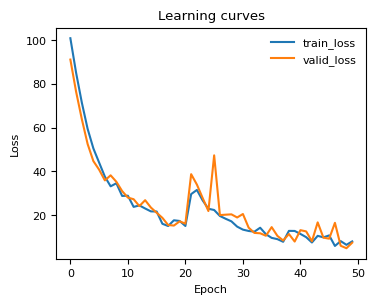

In [10]:
from mlcolvar.utils.plot import plot_metrics

fig, ax = plt.subplots(
    figsize=(4, 3)
)

plot_metrics(
    metrics.metrics,
    keys=["train_loss", "valid_loss"],
    yscale="linear",
    ax=ax,
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
plt.show()


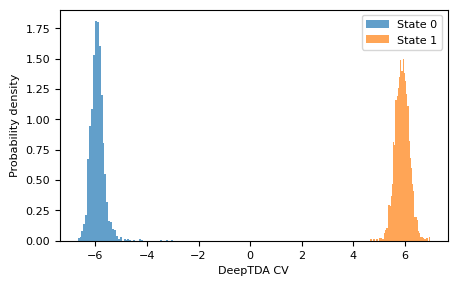

In [11]:
labels = (
    cached_dataset["labels"]
    .reshape(-1)
    .cpu()
)

plt.figure(
    figsize=(5, 3)
)

for state in torch.unique(labels):
    mask = labels == state

    plt.hist(
        cached_cv[mask].numpy(),
        bins=50,
        density=True,
        alpha=0.7,
        label=f"State {int(state)}",
    )

plt.xlabel("DeepTDA CV")
plt.ylabel("Probability density")
plt.legend()
plt.show()


## 10. Export through Metatomic

Deployment uses the complete raw-input model, not the cache:

```text
Metatomic System
      ↓
frozen MACE representation
      ↓
.pool(...)
      ↓
trained TaskHead
      ↓
DeepTDA CV
```

The cache is only a training optimization. `export_metatomic_model` exports the
full model and infers the output dimension, atomic types, interaction range,
dtype, and length unit from the representation metadata.


In [12]:
from mlcolvar.representation.metatomic import (
    export_metatomic_model,
)

raw_model = raw_model.cpu().eval()

export_path = Path(
    "deep_tda_mace_pooled_metatomic.pt"
)

export_metatomic_model(
    model=raw_model,
    path=export_path,
    supported_devices=["cpu"],
    name=(
        "mlcolvar DeepTDA with "
        "MACE representation"
    ),
    description=(
        "DeepTDA collective variable using a frozen "
        "MACE representation and a trained task head."
    ),
)

print(
    "Saved model:",
    export_path.resolve(),
)


/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(


Saved model: /home/kzhu-iit.local/data/mlcolvar-featurizer/docs/notebooks/tutorials/deep_tda_mace_pooled_metatomic.pt


### PLUMED example

```plumed
h: GROUP ATOMS=...
c: GROUP ATOMS=...
n: GROUP ATOMS=...
o: GROUP ATOMS=...

cv: METATOMIC ...
    MODEL=./deep_tda_mace_pooled_metatomic.pt
    DEVICE=cpu
    SPECIES1=h
    SPECIES2=c
    SPECIES3=n
    SPECIES4=o
    SPECIES_TO_TYPES=1,6,7,8
...

opes: OPES_METAD ...
    ARG=cv.node-0
    PACE=500
    TEMP=300
    BARRIER=40
...

PRINT ARG=cv.node-0,opes.* FILE=COLVAR STRIDE=500
```

A custom `GraphRepresentation` can use the same downstream training and export
workflow as long as it exposes the required representation metadata and its
model can be exported through the selected deployment path.
